<>:24: SyntaxWarning: invalid escape sequence '\A'
<>:67: SyntaxWarning: invalid escape sequence '\A'
<>:24: SyntaxWarning: invalid escape sequence '\A'
<>:67: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_2869/3985237791.py:24: SyntaxWarning: invalid escape sequence '\A'
  notdetect = ["N\A","NA","not reported", "unknown", "?"]
/tmp/ipykernel_2869/3985237791.py:67: SyntaxWarning: invalid escape sequence '\A'
  notdetect = ["N\A","NA","not reported", "unknown", "?"] # the unknown nulls to pandas


(2930, 82)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  Hou

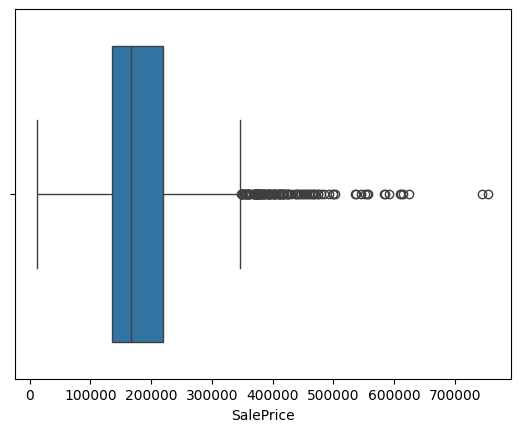

The 99% is 462029.9999999993
The Values above the 99%:
538000
611657
500000
501837
485000
555000
610000
582933
552000
468000
615000
475000
591587
492000
479069
500067
745000
466500
755000
545224
556581
535000
470000
465000
625000
584500
475000
The values have been Capped



-----------------THE THREE CHECKS--------------------
CHECK NUMBER ONE!
(No nulls)
CHECK NUMBER TWO!
(No negatives)
CHECK NUMBER THREE!
(I only dropped the 6 cols above)


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


def iqr_cal(s,k=3):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr =  q3 - q1
    return q1 - k * iqr, q3+k *iqr
#TASK7
def clean_data():
  # Enter the path to access data
  path = input("Whats the Datas' path?")
  #TASK1
  df = pd.read_csv(path)
  df.head()
  #TASK2
  print(df.shape)
  #TASK3
  df.info()
  print("Check the types, if there are any wrong ones CHANGE them")
  #TASK4
  notdetect = ["N\A","NA","not reported", "unknown", "?"]
  print("\nNUM OF NULL IN EACH COL\n-------------------------------------")
  df = df.dropna()

  #TASK5
  print(df.duplicated().sum())
  #TASK6
  tc = df["SalePrice"]
  lower, upper = iqr_cal(df[tc])
  print("\nIts BoxPlot:\n")
  sns.boxplot(data =df, x =tc)
  plt.show
  print("The Values above the 99%")
  for i in df[tc]:
    if i > df[tc].quantile(0.99):
      print(i)
  df[f"{tc}Capped"] = df[tc].clip(lower=lower, upper=upper)
  print("The values after capping:")
  for i in df[f"{tc}Capped"]:
    if i > df[f"{tc}Capped"].quantile(0.99):
      print(i)





#TASK 1
df = pd.read_csv("/content/AmesHousing.csv") # Read the dataset
df.head()# print the first 5

#TASK 2
print(df.shape) # (2930, 82)

#TASK 3
df.info()

#TASK4
#Droping Cols
df = df.drop(["Alley", "Mas Vnr Type", "Mas Vnr Area","Pool QC", "Misc Feature", "Fence", "Fireplace Qu", "Lot Frontage", "Pool Area", "Screen Porch", "3Ssn Porch", "Misc Val", "Enclosed Porch"], axis=1)


#Detection:
print("\nNUM OF NULL IN EACH COL\n-------------------------------------")
notdetect = ["N\A","NA","not reported", "unknown", "?"] # the unknown nulls to pandas
df = df.replace(notdetect, np.nan) # replacs the nulls unknown to pandas to the known
df = df.dropna() # drops rows if their is nan in it







#TASK 5
print(df.duplicated().sum()) #No dups

#TASK 6
sns.boxplot(data =df, x ="SalePrice")
plt.show()


lower, upper = iqr_cal(df["SalePrice"]) #iqr_cal at the top
o99 = df["SalePrice"].quantile(0.99)
print(f"The 99% is {o99}")
print("The Values above the 99%:")
for i in df["SalePrice"]:
  if i > o99:
    print(i)


df["SalePriceCapped"] = df["SalePrice"].clip(lower=lower, upper=upper)
print("The values have been Capped")


print("\n\n\n-----------------THE THREE CHECKS--------------------")
c1=0
c2=0
for i in df:
  if df[i].isna().sum()>=1:
    c1+=1
    print(f"THERE IS A NULL IN THE COL: {i}")
if c1==0:
    print("CHECK NUMBER ONE!\n(No nulls)")
for i in df["SalePrice"]:
  if i <= 0 :
    c2+=1
    print("THERE IS A NEGATIVE IN SALEPRICE")
if c2 == 0:
    print("CHECK NUMBER TWO!\n(No negatives)")
print("CHECK NUMBER THREE!\n(I only dropped the 6 cols above)")

